# Part 1

# TODO: Possibly add prediction error, check all parts are complete, figure out why line is below where it should be, verify in Colab


I used ChatGPT to understand the formulas given in the Linear Regression Optional Reading. I also used it to generate examples of linear regression from a theoretical standpoint in order to better understand the content. All code is my own

I first spent time understanding linear regression better. I read through the optional reading multiple times, and I asked ChatGPT to explain the variables in the mathematical equation. It took some time before I understood the proof behind the given algorithm. After that, I wrote it in Python on my own. On my first attempt, I failed to sum the errors across all data points. After fixing that, the model still did not work. I checked each line individually and found that I accidentally subracted instead of added in one location. 

h(x) = 1.7095936444387765e-07x + -139.9240509797051

I display several plots underneath my code, including the loss graph, slope and bias graphs, and the training and test data with the line of best fit marked. 

In [30]:
!pip install matplotlib
!pip install numpy

In [31]:
import matplotlib.pyplot as plt
import numpy as np

In [32]:
# Define learn function

def learn(num_iter, x_train, y_train):
    alpha = 0.001
    slope = 1 # Seed value
    slope_history = []
    bias_history = []
    error_history = []
    bias = 1 # Seed value
    params = np.array([slope, bias])

    j = 0

    while j < num_iter:
        x_j_input = x_train[j % len(x_train)]
        input_j = np.array([x_j_input, 1]) # Use 1 as the x input val for bias

        # Calculate sum of loss
        loss_sum = 0
        for n in range(len(x_train)):
            pred_val = np.sum(params * input_j) 
            loss = (y_train[n] - pred_val)
            loss_sum = loss_sum + loss
            loss_sum_scaled = loss_sum * input_j

        error_history.append(loss_sum)
        # Update theta
        params = params + alpha * loss_sum_scaled
        slope_history.append(params[0])
        bias_history.append(params[0])

        j = j + 1
    
    return params[0], params[1], slope_history, error_history


In [33]:
# Load Data

x_train = np.load("x_train.npy")
y_train = np.load("y_train.npy")
x_test = np.load("x_test.npy")
y_test = np.load("y_test.npy")

In [34]:
learned_slope, bias, slope_history, error_history = learn(200, x_train, y_train)
print(f"Learned slope: {learned_slope}")
print(f"Learned bias: {bias}")
print(f"Equation: h(x) = {learned_slope}x + {bias}")

Learned slope: 1.7095936444387765e-07
Learned bias: -139.9240509797051
Equation: h(x) = 1.7095936444387765e-07x + -139.9240509797051


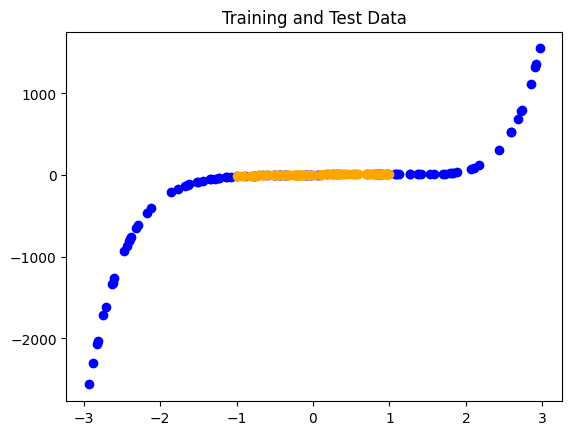

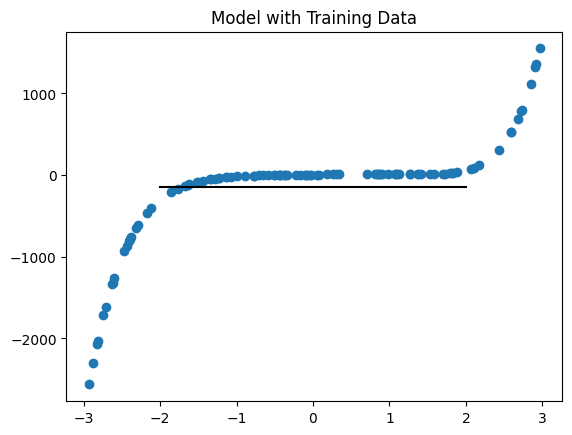

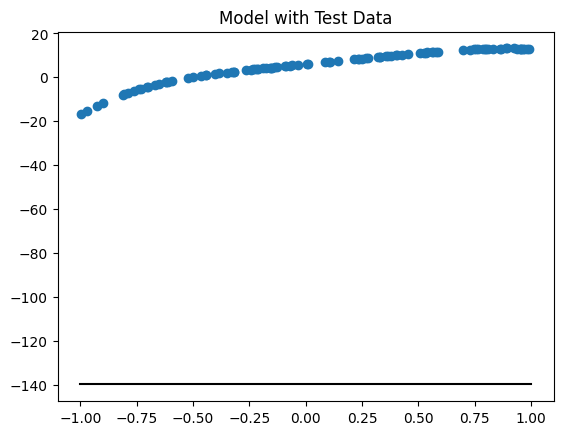

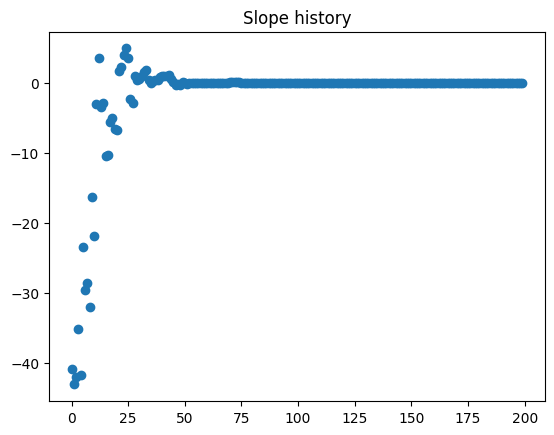

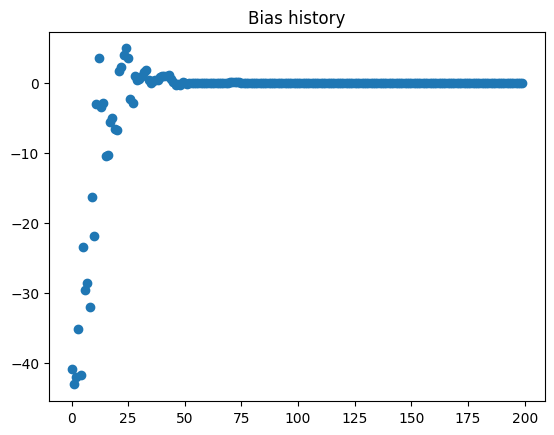

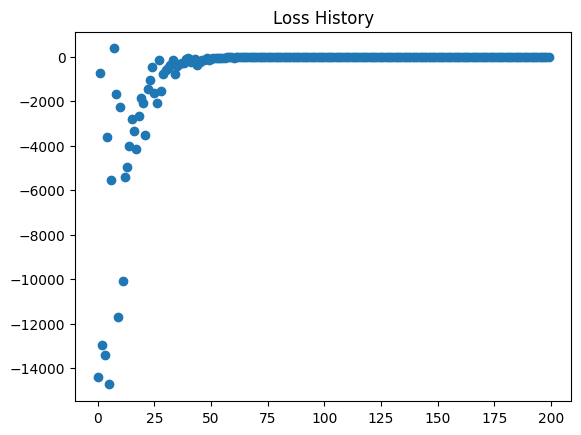

In [35]:
# Show results

plt.scatter(x_train, y_train, color="blue")
plt.scatter(x_test, y_test, color="orange")
plt.title("Training and Test Data")
plt.show()

plt.scatter(x_train, y_train)
plt.plot([-2, 0,2], [bias - 2 * learned_slope, bias, bias + 2 * learned_slope], color="black")
plt.title("Model with Training Data")
plt.show()

plt.scatter(x_test, y_test)
plt.plot([-1, 0,1], [bias - learned_slope, bias, bias + learned_slope], color="black")
plt.title("Model with Test Data")
plt.show()

plt.scatter([i for i in range(0, len(slope_history))], slope_history)
plt.title("Slope history")
plt.show()

plt.scatter([i for i in range(0, len(slope_history))], slope_history)
plt.title("Bias history")
plt.show()

plt.title("Loss History")
plt.scatter([i for i in range(0, len(error_history))], error_history)
plt.show()

# Part 2

## Status: working on loading CSVs correctly, then planning on running "learn" function on one to get it to work, then find a way to return a predicted error or other metric and run on all in loop, and pick the best fit one

In [46]:
housing_train = np.loadtxt("train.csv", delimiter=',', skiprows=1, dtype={'names': ('id', 'baths', 'land', 'living', 'garages', 'rooms','beds','age', 'price'), 'formats':('i2', 'f2', 'f4','f4', 'i4', 'i4', 'i4','i4','f8')})
#House ID,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Price

housing_train_land = housing_train[:2]
print(housing_train_land)

ValueError: could not convert string '1.5' to int32 at row 17, column 5.

In [ ]:
learned_slope, bias, slope_history, error_history = learn(200, x_train, y_train)
print(f"Learned slope: {learned_slope}")
print(f"Learned bias: {bias}")
print(f"Equation: h(x) = {learned_slope}x + {bias}")